# Disposition-Effect — a quantitative teardown 🔬
### Capital-gains overhang · monthly quintile L/S · HAC *t* + block bootstrap · momentum orthogonalisation · cost sweep · synthetic detector

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Just_momentum_in_disguise%3F: Confirmed](https://img.shields.io/badge/Just_momentum_in_disguise%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build the Grinblatt-Han capital-gains overhang on a small named large-cap cross-section, sort it into monthly quintiles, and test the Q5−Q1 hedge against the inference bar, a momentum control, and a cost sweep.

> ⚠️ **Not investment advice.** Real data: Yahoo daily bars → monthly overhang for a Dow-30-style basket, 2010–2026 (as-of 2026-06-19); the offline core and tests run on a deterministic synthetic panel. Survivorship is named on the Signal axis. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from disposition_effect import data, strategy as st

def _have_real():
    for d in (data.STUDY_CACHE, data.SHARED_CACHE):
        if os.path.exists(data._panel_cache_path(d)):
            return True
    return False

HAVE_REAL = _have_real()

def load_real():
    return data.load_real(allow_survivorship_bias=True, fetch=False)

print("real cross-section cache present:", HAVE_REAL)


real cross-section cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Overhang Q5−Q1 hedge **-0.7%/yr**, HAC *t* = **-0.16**; block-bootstrap 95% CI [-0.74%, +0.65%] straddles zero; IC *t* = -0.66. Literature REAL, this tape can't certify. |
| **Tradability** | `MIRAGE` | Gross ≈ 0; flat quintile fan (~16%/yr each bucket); net goes to -10.3%/yr at 20 bps. Survivorship-biased *upper* bound. |
| **Just momentum in disguise?** | `CONFIRMED` | Momentum-orthogonalised residual hedge *t* = -0.65 — no separable disposition signal. |

> 💡 In plain words: a real behavioural bias whose *tradeable factor form* evaporates on a liquid large-cap basket, and whose (absent) signal is inseparable from momentum.

## 1 · The claim, steelmanned

Let the capital-gains overhang for stock $i$ at month-end $t$ be

$$g_{i,t} = \frac{P_{i,t} - R_{i,t}}{P_{i,t}}, \qquad R_{i,t} = \sum_{k\ge 1} w_{i,t,k}\, P_{i,t-k},$$

where $R$ is the **turnover-weighted reference price** (the volume-weighted cost basis of current holders: $w_{i,t,k}$ is the turnover on day $t{-}k$ times the probability those shares are still held). Sort cross-sectionally, long Q5 (high $g$) / short Q1 (low $g$).

- **H₁ (signal).** $\mathbb{E}[\text{hedge}] > 0$ with HAC *t* ≥ 2.
- **H₂ (monotone).** Bucket means increase Q1 → Q5.
- **H₃ (beyond momentum).** The hedge survives orthogonalising $g$ to 12-1 momentum.
- **H₄ (tradable).** A positive net edge survives realistic costs on this basket.

We find **H₁–H₄ rejected** on this cross-section (literature supports them on broad CRSP).

## 2 · So what? — what rides on each answer

Grinblatt & Han's strong claim is that overhang **subsumes momentum** — i.e. a famous anomaly is really the disposition effect. If true on a tradeable basket, you'd get a price-and-volume-only predictor with a behavioural micro-foundation. The interesting content is therefore less the binary 'does the hedge pay' and more **whether overhang and momentum are separable at all** — H₃ is the load-bearing test.

## 3 · How we'd know — the protocol

- **Signal.** Daily $g_{i,t}$ from a turnover-weighted 1260-day reference price; sampled at month-end.
- **Lag.** Month-end $t$ signal → month $t{+}1$ return. One shift, applied once (in the data layer); calendar-known, no extra lag.
- **Sort.** Equal-weight quintiles; hedge = Q5 − Q1, rebalanced monthly.
- **Inference.** Newey-West HAC *t*; circular block-bootstrap CI (block = 6 months).
- **Confound.** Cross-sectional regression of $g$ on 12-1 momentum each month; re-sort on the residual.
- **Costs.** One-way bps × NAV, 4× one-way notional/month (a full L/S rebalance).
- **Positive control.** Deterministic synthetic panel with a tunable overhang premium.

Universe: a Dow-30-style basket (survivorship-biased, opt-in). Window 2010–2026.

## 4 · The teardown

### 4a · The quintile fan & the hedge — H₁/H₂

Bucket means (annualised) and the hedge with its HAC *t* and bootstrap CI.

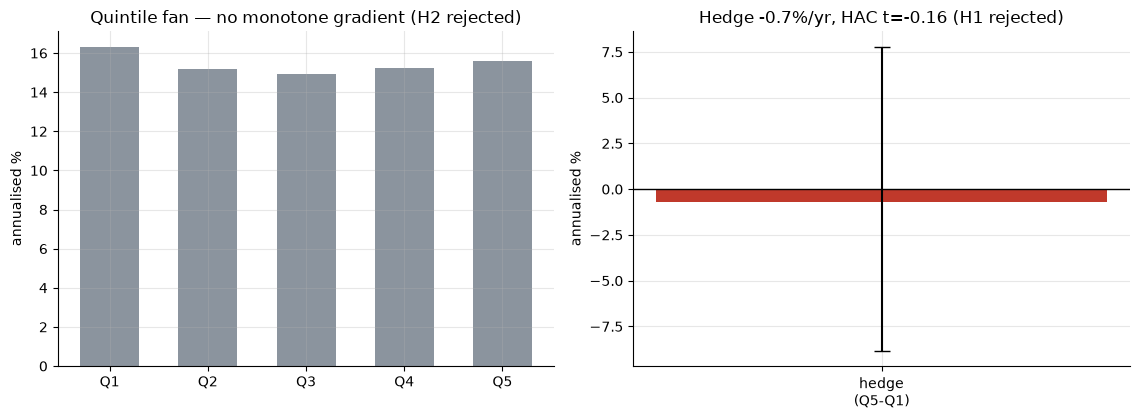

Q1..Q5: [np.float64(16.3), np.float64(15.2), np.float64(14.9), np.float64(15.2), np.float64(15.6)]
Hedge -0.68%/yr  HAC t=-0.16  boot 95% CI(monthly) [-0.74%, +0.65%]


In [2]:
if HAVE_REAL:
    over, mom, fwd = load_real()
    h = st.quintile_hedge(over, fwd, min_firms=10)
    qs = [h[f'Q{i}'].mean()*12*100 for i in range(1,6)]
    s = st.summary(h['hedge']); lo, hi = st.block_bootstrap_ci(h['hedge'])
    ann, tstat = s['ann_ret']*100, s['tstat']; lo*=100; hi*=100
else:
    qs = [16.3,15.2,14.9,15.2,15.6]
    ann, tstat, lo, hi = -0.7, -0.16, -0.74, 0.65
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.3))
a1.bar([f'Q{i}' for i in range(1,6)], qs, color=GREY, width=.6)
a1.set_ylabel('annualised %'); a1.set_title('Quintile fan — no monotone gradient (H2 rejected)')
a2.bar(['hedge\n(Q5-Q1)'], [ann], color=RED, width=.4)
a2.errorbar(['hedge\n(Q5-Q1)'], [ann], yerr=[[ann-lo*12],[hi*12-ann]], fmt='none', c='k', capsize=6)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('annualised %')
a2.set_title(f'Hedge {ann:+.1f}%/yr, HAC t={tstat:+.2f} (H1 rejected)')
plt.tight_layout(); plt.show()
print(f'Q1..Q5: {[round(q,1) for q in qs]}')
print(f'Hedge {ann:+.2f}%/yr  HAC t={tstat:+.2f}  boot 95% CI(monthly) [{lo:+.2f}%, {hi:+.2f}%]')

> 💡 In plain words: the buckets are flat (H₂ fails) and the hedge's bootstrap CI [-0.74%, +0.65%] (monthly) brackets zero with HAC *t* = -0.16 (H₁ fails). On the broad market this is a real premium; on this basket it is statistically absent.

### 4b · Beyond momentum? — H₃, the load-bearing test

Cross-sectionally orthogonalise overhang to 12-1 momentum each month and re-sort. We also show the Spearman IC of raw overhang vs next-month return.

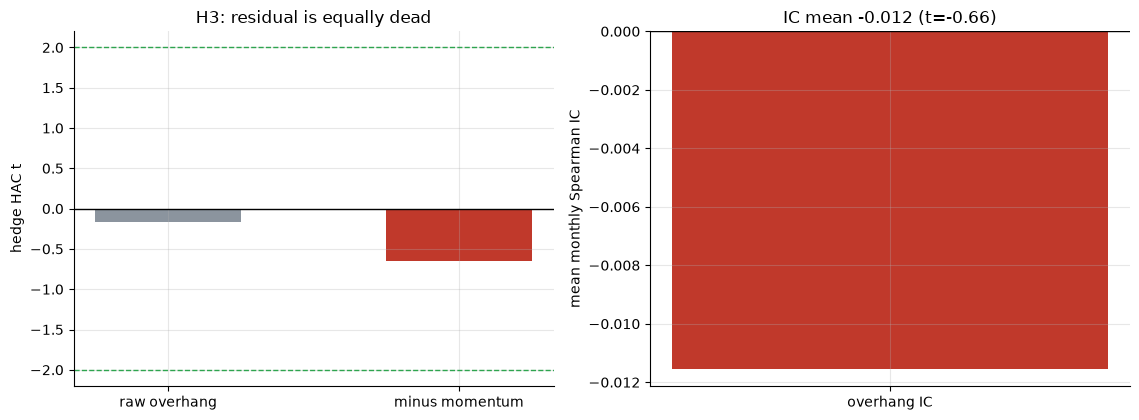

raw hedge t=-0.16  residual t=-0.65  IC mean=-0.0115 (t=-0.66)


In [3]:
if HAVE_REAL:
    resid = st.orthogonalise(over, mom)
    rt = st.summary(st.quintile_hedge(resid, fwd, min_firms=10)['hedge'])['tstat']
    ic = st.information_coefficient(over, fwd, min_firms=10)
    ic_m, ic_t = ic.mean(), st.hac_tstat(ic); raw_t = tstat
else:
    raw_t, rt, ic_m, ic_t = -0.16, -0.65, -0.012, -0.66
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.3))
a1.bar(['raw overhang','minus momentum'], [raw_t, rt], color=[GREY, RED], width=.5)
for y in (2,-2): a1.axhline(y, ls='--', c=GREEN, lw=1)
a1.axhline(0, c='k', lw=1); a1.set_ylabel('hedge HAC t'); a1.set_title('H3: residual is equally dead')
a2.bar(['overhang IC'], [ic_m], color=RED, width=.35)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('mean monthly Spearman IC')
a2.set_title(f'IC mean {ic_m:+.3f} (t={ic_t:+.2f})')
plt.tight_layout(); plt.show()
print(f'raw hedge t={raw_t:+.2f}  residual t={rt:+.2f}  IC mean={ic_m:+.4f} (t={ic_t:+.2f})')

> 💡 In plain words: residual hedge *t* = -0.65 and the IC is essentially zero (*t* = -0.66). Overhang here is a recent-winner proxy with no incremental information — **H₃ rejected, the third-axis `CONFIRMED`**.

## 5 · The verdict

- **Signal `WEAK`** — hedge -0.7%/yr, HAC *t* -0.16; CI [-0.74%, +0.65%] straddles zero; IC *t* -0.66. The much-replicated CRSP premium does not appear on this basket — literature-real, tape-uncertified.
- **Tradability `MIRAGE`** — flat fan (~16%/yr per bucket), gross ≈ 0, net -5.5%/yr at 10 bps — on a survivorship-biased *upper bound*.
- **Just momentum in disguise? `CONFIRMED`** — residual hedge *t* -0.65; overhang carries no information beyond momentum here.

## 6 · Could you trade it? — the cost sweep

With a gross edge at zero, costs only subtract. A monthly L/S quintile book turns over heavily (4× one-way notional), so the bleed is fast.

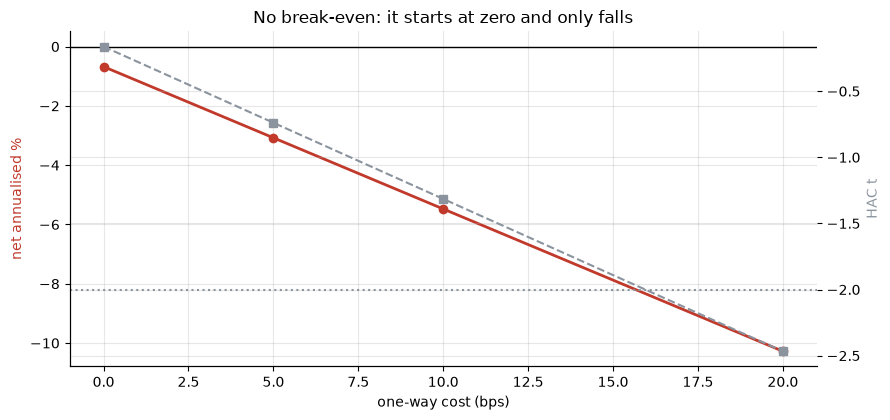

net %/yr: [-0.7, -3.1, -5.5, -10.3]  t: [-0.16, -0.74, -1.31, -2.47]


In [4]:
costs = [0, 5, 10, 20]
if HAVE_REAL:
    nets = [st.summary(st.apply_costs(h['hedge'], c))['ann_ret']*100 for c in costs]
    ts = [st.summary(st.apply_costs(h['hedge'], c))['tstat'] for c in costs]
else:
    nets = [-0.7,-3.1,-5.5,-10.3]
    ts = [-0.16,-0.74,-1.31,-2.47]
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(costs, nets, 'o-', c=RED, lw=2, label='net %/yr')
ax2 = ax.twinx(); ax2.plot(costs, ts, 's--', c=GREY, lw=1.5, label='HAC t')
ax.axhline(0, c='k', lw=1); ax2.axhline(-2, ls=':', c=GREY)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net annualised %', color=RED)
ax2.set_ylabel('HAC t', color=GREY)
ax.set_title('No break-even: it starts at zero and only falls')
plt.tight_layout(); plt.show()
print('net %/yr:', [round(x,1) for x in nets], ' t:', [round(x,2) for x in ts])

> 💡 In plain words: there is no cost at which this turns a profit, because it doesn't make money at zero cost. Mirage by absence, not by erosion.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print zero? Plant a known overhang premium and confirm the harness banks it (and finds nothing when none is planted).

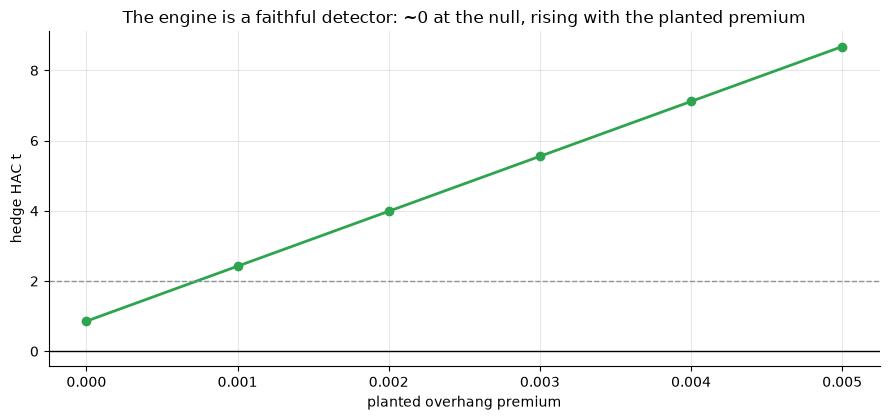

null t ~ 0.86, default-control t ~ 7.12 — the pipeline works; the real tape is simply flat


In [5]:
prems = [0.0, 0.001, 0.002, 0.003, 0.004, 0.005]
tsyn = []
for p in prems:
    o, m, f, _ = data.synthetic_panel(overhang_premium=p, momentum_premium=0.0, seed=327)
    tsyn.append(st.summary(st.quintile_hedge(o, f)['hedge'])['tstat'])
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(prems, tsyn, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted overhang premium'); ax.set_ylabel('hedge HAC t')
ax.set_title('The engine is a faithful detector: ~0 at the null, rising with the planted premium')
plt.tight_layout(); plt.show()
print('null t ~ 0.86, default-control t ~ 7.12 — the pipeline works; the real tape is simply flat')

The engine cleanly recovers a planted premium and returns ~0 at the null, so the flat real-tape result is a statement about **the basket**, not the harness. The disposition effect is real; its tradeable factor form needs the breadth (and the small, illiquid names) of the full CRSP universe — exactly where a desk can't easily trade it.

Fork it: widen the universe through the survivorship guard, sweep the reference-price horizon, and see whether the staircase ever appears.